In [1]:
# Получение данных из базы данных
import pandas as pd
import sqlite3
conn = sqlite3.connect(r"""E:\projects\Benefit Harm\apps\PC\data\students.db""")
df = pd.read_sql_query("select * from game_snapshots_v1", conn)
print(df.head(10))

   id  session_id  emotion  frequency_key_down  game_different  health  \
0   1          14  neutral                   2               0      10   
1   2          14      sad                   2              15      10   
2   3          14     fear                   2              15      10   
3   4          15      sad                   2               0      10   
4   5          15      sad                   3              15      10   
5   6          15      sad                   3              15      10   
6   7          17      sad                   1               0      10   
7   8          17      sad                   2              15      10   
8   9          17      sad                   3              15      10   
9  10          17      sad                   2              15      10   

                         time  enemy_distance status  count_defeat  
0  2026-08-15 08:36:26.258028             NaN   None           NaN  
1  2026-08-15 08:36:26.258028             NaN  

In [212]:
# Пустые значения
df = df.dropna(subset=["status"]).fillna(0)
print(df.isnull().sum())

id                    0
session_id            0
emotion               0
frequency_key_down    0
game_different        0
health                0
time                  0
enemy_distance        0
status                0
count_defeat          0
dtype: int64


In [213]:
# Разделение на y, x
y = df[["emotion"]]
X = df[["frequency_key_down",  "status", "count_defeat"]]

In [214]:
# Баланс классов
print(y.value_counts())

emotion 
sad         295
surprise    226
neutral      93
fear         76
happy        35
angry        26
Name: count, dtype: int64


In [215]:
# Строки
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
X['status'] = le.fit_transform(X['status'])
#X['time'] = pd.to_datetime(X['time'])
#X['time'] = X['time'].dt.hour

C:\Users\Work\AppData\Local\Temp\ipykernel_19972\1133817744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['status'] = le.fit_transform(X['status'])


In [216]:
# Разделение на тестовую и обучающую выборку
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (600, 3)
Тестовая выборка: (151, 3)


In [217]:
# Обучение модели
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

E:\projects\Benefit Harm\.venv10\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [218]:
# Оценка модели
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print(f"Матрица предсказаний: \n{confusion_matrix(y_test, y_pred)}")

Точность (Accuracy): 0.490
Матрица предсказаний: 
[[ 3  0  2  0  1  0]
 [ 1  1  2  2  6  0]
 [ 1  2  0  0  0  2]
 [ 2  3  5  6  5  0]
 [ 1  7  3 14 42  2]
 [ 3  0 11  2  0 22]]


count_defeat          0.335469
frequency_key_down   -0.571310
status               -1.182660
dtype: float64


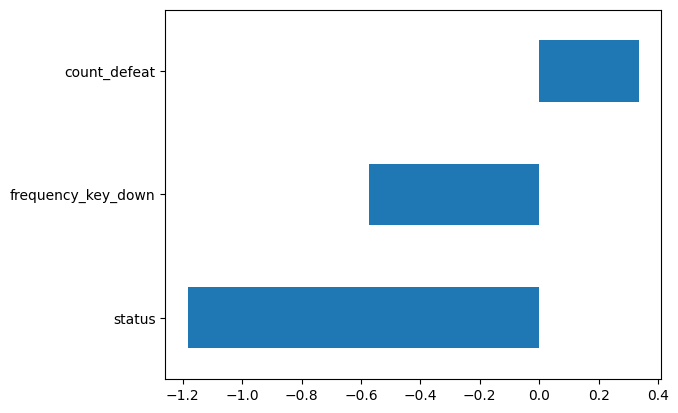

In [219]:
# Для LogisticRegression / LinearRegression
import matplotlib.pyplot as plt
coef = pd.Series(model.coef_[0], index=X.columns)
print(coef.sort_values(ascending=False))

# Визуализация
coef.sort_values().plot(kind='barh')
plt.show()